In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Promoter activity

In [3]:
orig_activity_k562 = pd.read_csv('data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/DNase_ENCFF257HEE_Neighborhoods/GeneList.txt', sep='\t')
orig_activity_gm12878 = pd.read_csv('data/GM12878_DNase_ENCFF020WZB_hic_4DNFI1UEG1HD_1MB_ABC_nominated/DNase_ENCFF020WZB_Neighborhoods/GeneList.txt', sep='\t')
orig_activity_k562

,chr,start,end,name,score,strand,symbol,tss,Expression,cellType,...,DHS.ENCFF257HEE.bam.RPM.TSS1Kb,DHS.ENCFF257HEE.bam.readCount.quantile.TSS1Kb,DHS.ENCFF257HEE.bam.RPM.quantile.TSS1Kb,DHS.ENCFF257HEE.bam.RPKM.TSS1Kb,DHS.ENCFF257HEE.bam.RPKM.quantile.TSS1Kb,DHS.RPM.TSS1Kb,DHS.RPM.quantile.TSS1Kb,DHS.RPKM.TSS1Kb,DHS.RPKM.quantile.TSS1Kb,PromoterActivityQuantile
0,chrX,100625428,100636750,ENSG00000000003,0,-,ENSG00000000003,100636750,NaN,K562,...,0.600308,0.222207,0.222207,0.600308,0.222207,0.600308,0.222207,0.600308,0.222207,0.248245
1,chrX,100584935,100600019,ENSG00000000005,0,+,ENSG00000000005,100584935,NaN,K562,...,0.176740,0.043995,0.043995,0.176740,0.043995,0.176740,0.043995,0.176740,0.043995,0.039805
2,chr20,50934842,50958531,ENSG00000000419,0,-,ENSG00000000419,50958531,NaN,K562,...,6.850214,0.597785,0.597785,6.850214,0.597785,6.850214,0.597785,6.850214,0.597785,0.791478
3,chr1,169849258,169893895,ENSG00000000457,0,-,ENSG00000000457,169893895,NaN,K562,...,20.270295,0.950482,0.950482,20.270295,0.950482,20.270295,0.950482,20.270295,0.950482,0.993198
4,chr1,169795044,169987021,ENSG00000000460,0,+,ENSG00000000460,169795044,NaN,K562,...,9.900509,0.729281,0.729281,9.900509,0.729281,9.900509,0.729281,9.900509,0.729281,0.887849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18372,chr20,36574515,36612347,ENSG00000259399,0,+,ENSG00000259399,36574515,NaN,K562,...,5.366204,0.531779,0.531779,5.366204,0.531779,5.366204,0.531779,5.366204,0.531779,0.559776
18373,chr14,23556270,23560535,ENSG00000259431,0,+,ENSG00000259431,23556270,NaN,K562,...,6.201150,0.568428,0.568428,6.201150,0.568428,6.201150,0.568428,6.201150,0.568428,0.602275
18374,chr15,84172490,84182235,ENSG00000259511,0,+,ENSG00000259511,84172490,NaN,K562,...,0.466229,0.169995,0.169995,0.466229,0.169995,0.466229,0.169995,0.466229,0.169995,0.288186
18375,chr11,122115353,122116215,ENSG00000259571,0,-,ENSG00000259571,122116215,NaN,K562,...,0.234638,0.066823,0.066823,0.234638,0.066823,0.234638,0.066823,0.234638,0.066823,0.057599


In [38]:
ihec_activity_k562 = pd.read_csv('data/IHEC-ChIP-Seq-Histone-Signals/PromotersK562.H3K27ac.tab', sep='\t', names=['gene_id', 'size', 'covered', 'sum', 'mean0', 'mean'])
ihec_activity_gm12878 = pd.read_csv('data/IHEC-ChIP-Seq-Histone-Signals/PromotersGM12878.H3K27ac.tab', sep='\t', names=['gene_id', 'size', 'covered', 'sum', 'mean0', 'mean'])
ihec_activity_k562

,gene_id,size,covered,sum,mean0,mean
0,ENSG00000186092,1000,1000,0.000,0.000000,0.000000
1,ENSG00000187634,1000,1000,122.686,0.122686,0.122686
2,ENSG00000188976,1000,1000,7424.410,7.424410,7.424410
3,ENSG00000187961,1000,1000,5172.200,5.172200,5.172200
4,ENSG00000187583,1000,1000,5719.150,5.719150,5.719150
...,...,...,...,...,...,...
18372,ENSG00000155962,1000,1000,8528.710,8.528710,8.528710
18373,ENSG00000168939,1000,1000,25763.000,25.763000,25.763000
18374,ENSG00000185973,1000,1000,26074.200,26.074200,26.074200
18375,ENSG00000124333,1000,1000,19404.800,19.404800,19.404800


In [39]:
# count how often something other than 1000 appears in the covered column
non_1000_count = (ihec_activity_k562['covered'] != 1000).sum()
non_1000_count_gm12878 = (ihec_activity_gm12878['covered'] != 1000).sum()
print(f"Number of entries with 'covered' not equal to 1000: {non_1000_count}")
print(f"Number of entries with 'covered' not equal to 1000 (GM12878): {non_1000_count_gm12878}")

Number of entries with 'covered' not equal to 1000: 1
Number of entries with 'covered' not equal to 1000 (GM12878): 2


In [40]:
ihec_activity_k562 = ihec_activity_k562.merge(orig_activity_k562[['symbol', 'H3K27ac.RPM.TSS1Kb']], left_on='gene_id', right_on='symbol', how='left')
ihec_activity_k562 = ihec_activity_k562[['gene_id', 'size', 'covered', 'mean0', 'mean', 'H3K27ac.RPM.TSS1Kb']]

In [41]:
ihec_activity_k562

,gene_id,size,covered,mean0,mean,H3K27ac.RPM.TSS1Kb
0,ENSG00000186092,1000,1000,0.000000,0.000000,0.004714
1,ENSG00000187634,1000,1000,0.122686,0.122686,0.268734
2,ENSG00000188976,1000,1000,7.424410,7.424410,4.783962
3,ENSG00000187961,1000,1000,5.172200,5.172200,2.199607
4,ENSG00000187583,1000,1000,5.719150,5.719150,3.587233
...,...,...,...,...,...,...
18372,ENSG00000155962,1000,1000,8.528710,8.528710,8.074045
18373,ENSG00000168939,1000,1000,25.763000,25.763000,12.016016
18374,ENSG00000185973,1000,1000,26.074200,26.074200,11.245005
18375,ENSG00000124333,1000,1000,19.404800,19.404800,13.044522


In [42]:
ihec_activity_gm12878 = ihec_activity_gm12878.merge(orig_activity_gm12878[['symbol', 'H3K27ac.RPM.TSS1Kb']], left_on='gene_id', right_on='symbol', how='left')
ihec_activity_gm12878 = ihec_activity_gm12878[['gene_id', 'size', 'covered', 'mean0', 'mean', 'H3K27ac.RPM.TSS1Kb']]

In [43]:
# drop na rows
ihec_activity_k562 = ihec_activity_k562.dropna(subset=['H3K27ac.RPM.TSS1Kb'])
ihec_activity_gm12878 = ihec_activity_gm12878.dropna(subset=['H3K27ac.RPM.TSS1Kb'])

In [44]:
def plot_promoter_activity_correlation(activity_df, title, ax):
    pearsonr, _ = stats.pearsonr(activity_df['mean'], activity_df['H3K27ac.RPM.TSS1Kb'])
    sns.scatterplot(data=activity_df, x='mean', y='H3K27ac.RPM.TSS1Kb', alpha=0.5, ax=ax)
    sns.regplot(data=activity_df, x='mean', y='H3K27ac.RPM.TSS1Kb', scatter=False, color='red', label=f'Pearson r={pearsonr:.2f}', ax=ax)
    ax.set_xlabel('IHEC H3K27ac Mean')
    ax.set_ylabel('ENCODE H3K27ac')
    ax.set_title(title)
    ax.legend()

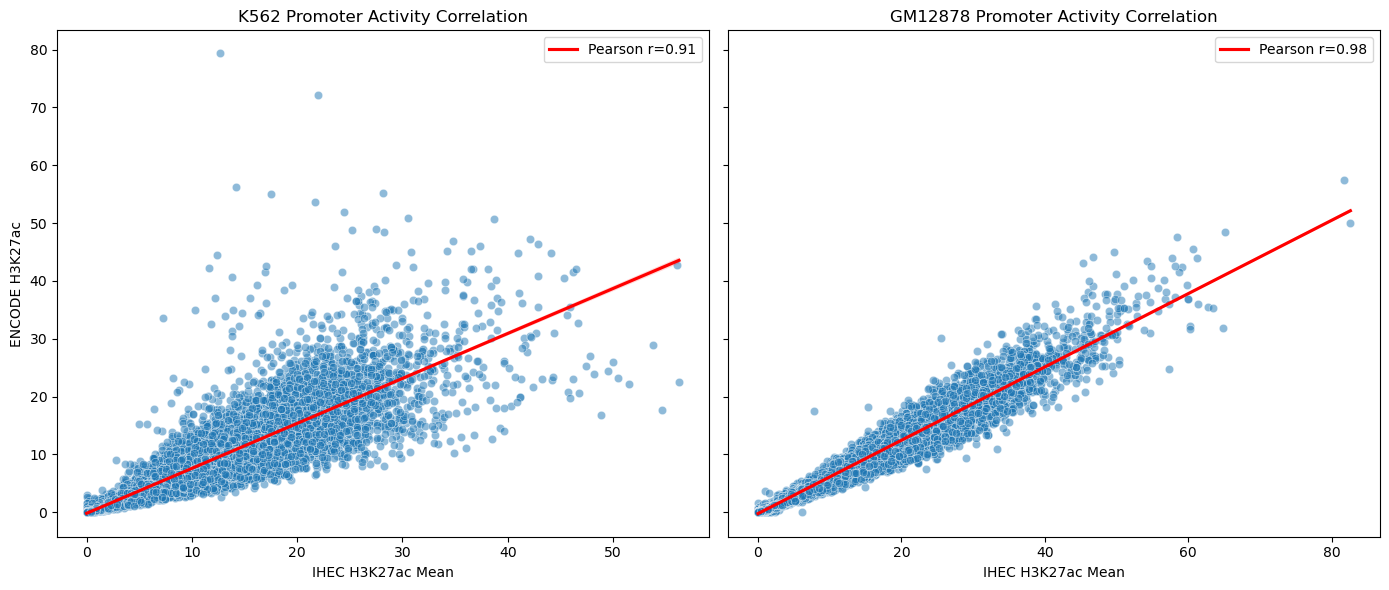

In [46]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)
plot_promoter_activity_correlation(ihec_activity_k562, 'K562 Promoter Activity Correlation', ax1)
plot_promoter_activity_correlation(ihec_activity_gm12878, 'GM12878 Promoter Activity Correlation', ax2)
plt.tight_layout()
plt.show()

## Check other histone signals

In [ ]:
histone_signals_k562 = pd.read_csv('data/IHEC-ChIP-Seq-Histone-Signals/Promoter_Combined_K562_Histone_Signals.csv', sep=',')
histone_signals_gm12878 = pd.read_csv('data/IHEC-ChIP-Seq-Histone-Signals/Promoter_Combined_GM12878_Histone_Signals.csv', sep=',')
histone_signals_k562

,gene_id,covered,H3K27ac.mean,H3K27me3.mean,H3K36me3.mean,H3K4me1.mean,H3K4me3.mean,H3K9me3.mean
0,ENSG00000186092,1000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,ENSG00000187634,1000,0.122686,0.620256,0.037355,26.322300,3.028900,0.055485
2,ENSG00000188976,1000,7.424410,0.812435,0.584804,12.919200,19.222500,0.483096
3,ENSG00000187961,1000,5.172200,0.002291,0.357234,15.954900,20.710800,0.280394
4,ENSG00000187583,1000,5.719150,0.451246,0.380420,37.801600,7.794600,0.591104
...,...,...,...,...,...,...,...,...
18372,ENSG00000155962,1000,8.528710,0.054322,0.297257,0.485921,5.461430,0.359953
18373,ENSG00000168939,1000,25.763000,0.125218,0.404569,2.722380,19.724500,0.513137
18374,ENSG00000185973,1000,26.074200,0.134628,0.324383,3.261800,17.967700,0.592924
18375,ENSG00000124333,1000,19.404800,0.232984,0.411508,1.019420,11.799200,0.460992


In [48]:
# drop rows where covered is not 1000
histone_signals_k562 = histone_signals_k562[histone_signals_k562['covered'] == 1000]
histone_signals_gm12878 = histone_signals_gm12878[histone_signals_gm12878['covered'] == 1000]

In [50]:
# melt the dataframe to have a signal column and a histone type column
histone_signals_k562_melted = histone_signals_k562.melt(id_vars=['gene_id', 'covered'], var_name='histone_type', value_name='signal')
histone_signals_gm12878_melted = histone_signals_gm12878.melt(id_vars=['gene_id', 'covered'], var_name='histone_type', value_name='signal')
histone_signals_k562_melted

,gene_id,covered,histone_type,signal
0,ENSG00000186092,1000,H3K27ac.mean,0.000000
1,ENSG00000187634,1000,H3K27ac.mean,0.122686
2,ENSG00000188976,1000,H3K27ac.mean,7.424410
3,ENSG00000187961,1000,H3K27ac.mean,5.172200
4,ENSG00000187583,1000,H3K27ac.mean,5.719150
...,...,...,...,...
110251,ENSG00000155962,1000,H3K9me3.mean,0.359953
110252,ENSG00000168939,1000,H3K9me3.mean,0.513137
110253,ENSG00000185973,1000,H3K9me3.mean,0.592924
110254,ENSG00000124333,1000,H3K9me3.mean,0.460992


In [57]:
# combine the two melted dataframes
histone_signals_k562_melted['cell_type'] = 'K562'
histone_signals_gm12878_melted['cell_type'] = 'GM12878'
histone_signals_melted_combined = pd.concat([histone_signals_k562_melted, histone_signals_gm12878_melted], ignore_index=True)
histone_signals_melted_combined

,gene_id,covered,histone_type,signal,cell_type
0,ENSG00000186092,1000,H3K27ac.mean,0.000000,K562
1,ENSG00000187634,1000,H3K27ac.mean,0.122686,K562
2,ENSG00000188976,1000,H3K27ac.mean,7.424410,K562
3,ENSG00000187961,1000,H3K27ac.mean,5.172200,K562
4,ENSG00000187583,1000,H3K27ac.mean,5.719150,K562
...,...,...,...,...,...
220501,ENSG00000155962,1000,H3K9me3.mean,1.489730,GM12878
220502,ENSG00000168939,1000,H3K9me3.mean,2.160550,GM12878
220503,ENSG00000185973,1000,H3K9me3.mean,2.557530,GM12878
220504,ENSG00000124333,1000,H3K9me3.mean,1.486290,GM12878


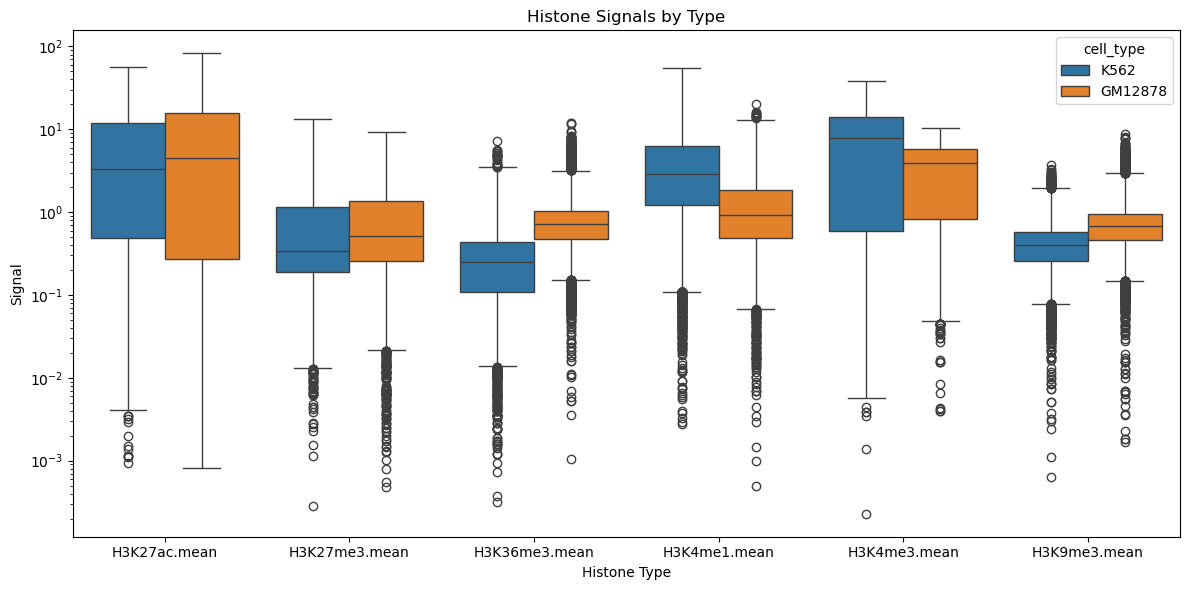

In [59]:
# plot box plots for each histone type
plt.figure(figsize=(12, 6))
sns.boxplot(data=histone_signals_melted_combined, x='histone_type', y='signal', log_scale=True, hue='cell_type')
plt.xticks(rotation=0)
plt.title('Histone Signals by Type')
plt.xlabel('Histone Type')
plt.ylabel('Signal')
plt.tight_layout()
plt.show()

# Enhancer activity

In [9]:
histone_signals_k562 = pd.read_csv('data/IHEC-ChIP-Seq-Histone-Signals/Enhancer_Combined_K562_Histone_Signals.csv', sep=',')
histone_signals_gm12878 = pd.read_csv('data/IHEC-ChIP-Seq-Histone-Signals/Enhancer_Combined_GM12878_Histone_Signals.csv', sep=',')
histone_signals_k562

,gene_id,covered,H3K27ac.mean,H3K27me3.mean,H3K36me3.mean,H3K4me1.mean,H3K4me3.mean,H3K9me3.mean
0,intergenic|chr1:585952-586452,500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,intergenic|chr1:605341-605841,500,0.883907,0.000000,0.000000,2.214580,1.037200,0.118716
2,intergenic|chr1:629686-630186,500,0.000000,0.414857,0.000000,0.251587,0.244210,0.516884
3,intergenic|chr1:633778-634278,500,0.000000,0.541511,0.000000,0.223356,0.000000,0.265364
4,intergenic|chr1:778388-779144,756,7.614350,0.174603,0.185843,1.272530,11.882000,0.245840
...,...,...,...,...,...,...,...,...
116664,intergenic|chrY:11329663-11330163,500,0.000000,0.160427,0.000000,0.000000,2.281950,0.502922
116665,intergenic|chrY:11333773-11334507,734,0.266555,0.218565,0.000000,1.598500,0.227501,1.150730
116666,intergenic|chrY:11712120-11712620,500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
116667,intergenic|chrY:56849825-56850381,556,1.055700,0.297649,0.710372,0.034348,1.433290,1.027910


In [10]:
histone_signals_k562_melted = histone_signals_k562.melt(id_vars=['gene_id', 'covered'], var_name='histone_type', value_name='signal')
histone_signals_gm12878_melted = histone_signals_gm12878.melt(id_vars=['gene_id', 'covered'], var_name='histone_type', value_name='signal')
histone_signals_k562_melted['cell_type'] = 'K562'
histone_signals_gm12878_melted['cell_type'] = 'GM12878'
histone_signals_melted_combined = pd.concat([histone_signals_k562_melted, histone_signals_gm12878_melted], ignore_index=True)
histone_signals_melted_combined

,gene_id,covered,histone_type,signal,cell_type
0,intergenic|chr1:585952-586452,500,H3K27ac.mean,0.000000,K562
1,intergenic|chr1:605341-605841,500,H3K27ac.mean,0.883907,K562
2,intergenic|chr1:629686-630186,500,H3K27ac.mean,0.000000,K562
3,intergenic|chr1:633778-634278,500,H3K27ac.mean,0.000000,K562
4,intergenic|chr1:778388-779144,756,H3K27ac.mean,7.614350,K562
...,...,...,...,...,...
1508857,intergenic|chrY:56860276-56860776,500,H3K9me3.mean,0.233260,GM12878
1508858,intergenic|chrY:56870817-56871778,961,H3K9me3.mean,1.039640,GM12878
1508859,intergenic|chrY:56872679-56873179,500,H3K9me3.mean,0.173332,GM12878
1508860,intergenic|chrY:56873407-56873907,500,H3K9me3.mean,0.342556,GM12878


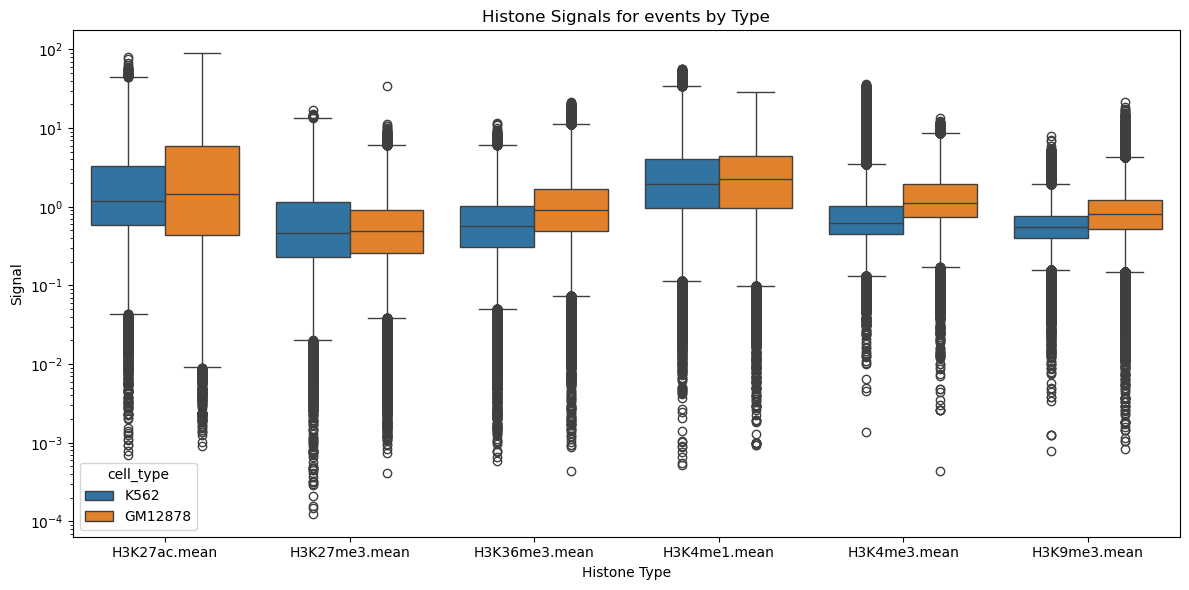

In [11]:
# plot box plots for each histone type
plt.figure(figsize=(12, 6))
sns.boxplot(data=histone_signals_melted_combined, x='histone_type', y='signal', log_scale=True, hue='cell_type')
plt.xticks(rotation=0)
plt.title('Histone Signals for events by Type')
plt.xlabel('Histone Type')
plt.ylabel('Signal')
plt.tight_layout()
plt.show()

# Event activity

In [4]:
histone_signals_k562 = pd.read_csv('data/IHEC-ChIP-Seq-Histone-Signals/Events_Combined_K562_Histone_Signals.csv', sep=',')
histone_signals_gm12878 = pd.read_csv('data/IHEC-ChIP-Seq-Histone-Signals/Events_Combined_GM12878_Histone_Signals.csv', sep=',')
histone_signals_k562

,gene_id,covered,H3K27ac.mean,H3K27me3.mean,H3K36me3.mean,H3K4me1.mean,H3K4me3.mean,H3K9me3.mean
0,intron1|ENSG00000224051;SE:chr1:1325102-132683...,1024,2.077580,0.495509,1.04915,12.01370,2.487770,0.403888
1,exon|ENSG00000224051;SE:chr1:1325102-1326836:1...,196,1.449600,0.994073,3.08687,5.12244,1.032610,0.549963
2,intron2|ENSG00000224051;SE:chr1:1325102-132683...,209,0.816318,0.781234,1.46794,7.26510,1.054710,0.545655
3,intron1|ENSG00000160072;SE:chr1:1486668-148786...,1024,0.000000,0.350202,2.01366,1.56203,0.209288,0.540433
4,exon|ENSG00000160072;SE:chr1:1486668-1487863:1...,51,0.000000,1.368630,2.60509,2.62132,0.458180,0.000000
...,...,...,...,...,...,...,...,...
74848,exon|ENSG00000196433;AR:chrY:1624398-1627703:1...,68,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
74849,intron2|ENSG00000196433;AR:chrY:1624398-162770...,1024,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
74850,intron1|ENSG00000197976;AR:chrY:1595532-159919...,1024,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
74851,exon|ENSG00000197976;AR:chrY:1595532-1599192:1...,240,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000


In [6]:
# melt and combine the dataframes
histone_signals_k562_melted = histone_signals_k562.melt(id_vars=['gene_id', 'covered'], var_name='histone_type', value_name='signal')
histone_signals_gm12878_melted = histone_signals_gm12878.melt(id_vars=['gene_id', 'covered'], var_name='histone_type', value_name='signal')
histone_signals_k562_melted['cell_type'] = 'K562'
histone_signals_gm12878_melted['cell_type'] = 'GM12878'
histone_signals_melted_combined = pd.concat([histone_signals_k562_melted, histone_signals_gm12878_melted], ignore_index=True)
histone_signals_melted_combined

,gene_id,covered,histone_type,signal,cell_type
0,intron1|ENSG00000224051;SE:chr1:1325102-132683...,1024,H3K27ac.mean,2.077580,K562
1,exon|ENSG00000224051;SE:chr1:1325102-1326836:1...,196,H3K27ac.mean,1.449600,K562
2,intron2|ENSG00000224051;SE:chr1:1325102-132683...,209,H3K27ac.mean,0.816318,K562
3,intron1|ENSG00000160072;SE:chr1:1486668-148786...,1024,H3K27ac.mean,0.000000,K562
4,exon|ENSG00000160072;SE:chr1:1486668-1487863:1...,51,H3K27ac.mean,0.000000,K562
...,...,...,...,...,...
898231,exon|ENSG00000196433;AR:chrY:1624398-1627703:1...,68,H3K9me3.mean,0.000000,GM12878
898232,intron2|ENSG00000196433;AR:chrY:1624398-162770...,1024,H3K9me3.mean,0.000000,GM12878
898233,intron1|ENSG00000197976;AR:chrY:1595532-159919...,1024,H3K9me3.mean,0.000000,GM12878
898234,exon|ENSG00000197976;AR:chrY:1595532-1599192:1...,240,H3K9me3.mean,0.000000,GM12878


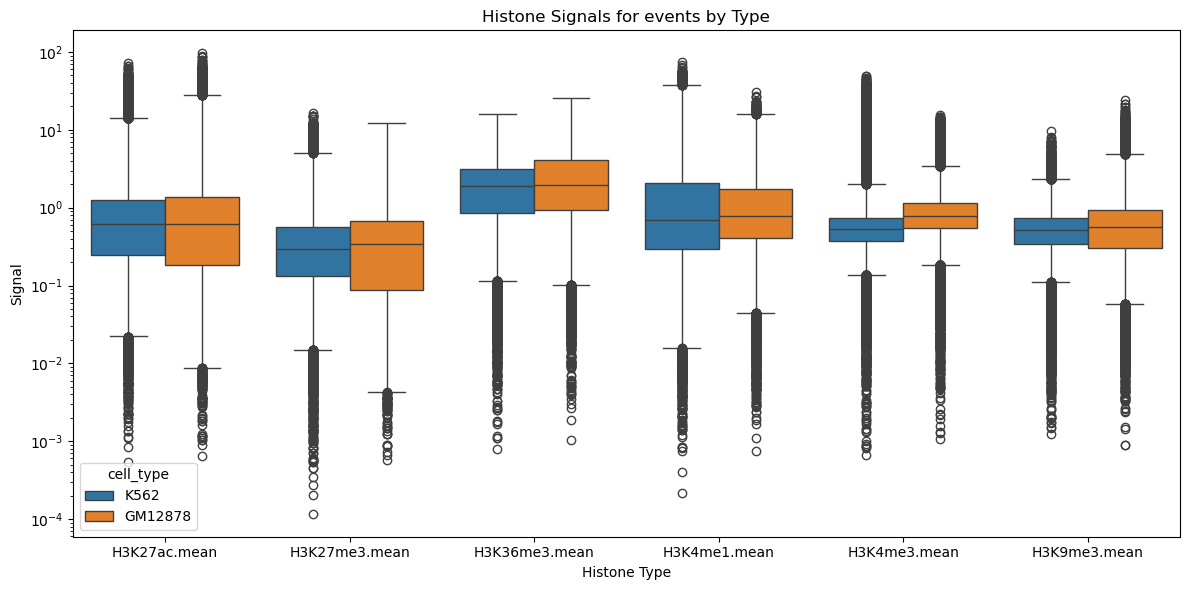

In [8]:
# plot box plots for each histone type
plt.figure(figsize=(12, 6))
sns.boxplot(data=histone_signals_melted_combined, x='histone_type', y='signal', log_scale=True, hue='cell_type')
plt.xticks(rotation=0)
plt.title('Histone Signals for events by Type')
plt.xlabel('Histone Type')
plt.ylabel('Signal')
plt.tight_layout()
plt.show()